## Chunk Construction & BM25

In [ ]:
from pathlib import Path
from rank_bm25 import BM25Okapi

In [ ]:
# Path for chunks
RAW = Path("/content/data/raw")
RAW.mkdir(parents=True, exist_ok=True)

In [ ]:
import re
from pathlib import Path

def load_and_chunk_structured(raw_dir=RAW):
    """
    It creates the chunks from the documents.

    The function returns:
      chunks: formatted text passages (Country / Section / Text)
      meta: metadata for each chunk (country, section, word span)
    """
    chunks, meta = [], []
    for p in Path(raw_dir).glob("**/*.txt"):
        country = p.stem
        text = p.read_text(encoding="utf-8", errors="ignore").strip()
        paras = [para.strip() for para in re.split(r"\n{2,}", text) if para.strip()] # Split documents by empty lines

        start_word = 0
        for para in paras:
            lines = para.splitlines()
            first = (lines[0].strip() if lines else "")
            is_upper_header = any(c.isalpha() for c in first) and first.upper() == first

            if is_upper_header:
                section = first
                body = "\n".join(lines[1:]).strip()
            else:
                section = "GENERAL"
                body = para

            # Final chunk format
            piece = f"Country: {country}\nSection: {section}\nText:\n{body}"
            chunks.append(piece)

            # Store metadata
            wcount = len(body.split())
            meta.append({
                "doc": p.name,
                "country": country,
                "section": section,
                "start": start_word,
                "end": start_word + wcount,
            })
            start_word += wcount

    return chunks, meta

# Build chunks and metadata
chunks, meta = load_and_chunk_structured()
len(chunks), meta[:2]


(318,
 [{'doc': 'United States.txt',
   'country': 'United States',
   'section': 'LOCATION',
   'start': 0,
   'end': 17},
  {'doc': 'United States.txt',
   'country': 'United States',
   'section': 'GEOGRAPHIC COORDINATES',
   'start': 17,
   'end': 23}])

In [ ]:
texts = [f"passage: {c}" for c in chunks] # Prepare texts for dense retrieval
ids   = [f"{m['country']}|{m['section']}|{i:03d}"
         for i, m in enumerate(meta)] # Stable chunk identifiers

In [ ]:
# Country router utilities

from pathlib import Path
import re

AVAILABLE_COUNTRIES = sorted({Path(m["doc"]).stem for m in meta}) # Available countries

def _normalize(s: str) -> str:
    """Normalize text for case-insensitive and whitespace-robust matching."""
    return re.sub(r"\s+", " ", s.strip().lower())

def extract_countries_from_query(query: str) -> list[str]:
    """Extract country names explicitly mentioned in the query."""
    qn = _normalize(query)
    found = set()

    # Match diretto sui nomi ufficiali (come compaiono negli .txt)
    for c in AVAILABLE_COUNTRIES:
        if re.search(rf"\b{re.escape(c.lower())}\b", qn):
            found.add(c)

    return sorted(found)

def meta_country(i: int) -> str:
    """Restituisce lo stem del documento (Paese) per il chunk i-esimo."""
    return Path(meta[i]["doc"]).stem


In [ ]:
# BM25

tokenized = [c.lower().split() for c in chunks] # Tokenize chunks
bm25 = BM25Okapi(tokenized) # Initialize BM25 over all chunks

def bm25_topk(query, k=5):
    """Retrieve the top-k chunks using BM25 scoring."""
    q = query.lower().split()
    scores = bm25.get_scores(q)
    idx = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)[:k] # Select top-k chunks by BM25 score
    return [
        {
            "rank": r+1,
            "idx": i,
            "score": float(scores[i]),
            "chunk": chunks[i],
            "doc": meta[i]["doc"],
            "span": (meta[i]["start"], meta[i]["end"]),
        }
        for r, i in enumerate(idx)
    ]

## Dense

In [ ]:
# Dense

from sentence_transformers import SentenceTransformer
import numpy as np, faiss

embed_model = SentenceTransformer("intfloat/multilingual-e5-base") # Sentence embedding model

# Encoding all chunks
doc_texts = [f"passage: {chunks[i]}" for i in range(len(chunks))]
doc_emb = embed_model.encode(
    doc_texts,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,    # così cosine = dot product
)

# FAISS index for fast inner-product search over normalized embeddings
index = faiss.IndexFlatIP(doc_emb.shape[1])
index.add(doc_emb)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

In [ ]:
def dense_topk(query: str, k: int = 5):
    """Retrieve the top-k chunks using dense vector similarity."""
    q_emb = embed_model.encode([f"query: {query}"], convert_to_numpy=True, normalize_embeddings=True)
    # Search the FAISS index
    D, I = index.search(q_emb, k)  # D = similarity scores, I = chunk indices
    out = []
    for rank, (idx, score) in enumerate(zip(I[0], D[0]), start=1):
        out.append({
            "rank": rank,
            "idx": int(idx),
            "score": float(score),
            "chunk": chunks[idx],
            "doc": meta[idx]["doc"],
            "span": (meta[idx]["start"], meta[idx]["end"]),
        })
    return out


## Graph Co-occurence Construction Intra-Country

In [ ]:
import re
from collections import defaultdict, Counter
from itertools import combinations

import spacy
import networkx as nx

## Construction of the co-occurence graph (intra-country)


# Spacy model
def load_spacy():
    """Load a lightweight English spaCy pipeline."""
    try:
        return spacy.load("en_core_web_sm")
    except OSError:
        import os
        os.system("python -m spacy download en_core_web_sm")
        return spacy.load("en_core_web_sm")

NLP = load_spacy()

# Minimal stopword list for noun-phrase cleanup
STOP = set("""
a an the and or of in on for to with by from as at is are was were be been being
this that these those it its their his her
""".split())

# Single-token concepts that are too generic in this dataset
GENERIC_SINGLE_TOKS = {"total","male","female","note","km","years","year","est","m","nm"}

# Chunk parsing and normalization
def parse_factbook_chunk(chunk: str):
    """Parse the structured chunk format: Country / Section / Text."""

    country = None
    section = None
    body = ""

    m = re.search(r"^Country:\s*(.+)$", chunk, flags=re.M)
    if m: country = m.group(1).strip()

    m = re.search(r"^Section:\s*(.+)$", chunk, flags=re.M)
    if m: section = m.group(1).strip()

    m = re.search(r"\nText:\n(.*)$", chunk, flags=re.S)
    if m: body = m.group(1).strip()

    return country, section, body

def clean_phrase(s: str) -> str:
    """Normalize concept strings"""
    s = (s or "").strip().lower()
    s = re.sub(r"[^a-z0-9\s\-/%]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def is_specific_section(section: str) -> bool:
    """Heuristic to decide whether a section title is informative
    enough to be used as a concept."""
    if not section:
        return False
    s = clean_phrase(section)
    whitelist = {
        "maritime claims", "land boundaries", "geography - note",
        "natural hazards", "major rivers (by length in km)",
        "major watersheds (area sq km)", "major aquifers",
        "population distribution"
    }
    if s in whitelist:
        return True
    if " - " in section:
        return True
    if len(s) >= 22:
        return True
    return False

In [ ]:
# Section grouping
def section_group(section: str) -> str | None:
    """Map fine-grained section names to a small set of coarse topic groups.
    This reduces noise when linking chunks and encourages topic-consistent edges."""
    if not section:
        return None
    s = clean_phrase(section)

    # Simple map
    if any(k in s for k in ["coastline", "maritime claims"]):
        return "maritime"
    if any(k in s for k in ["land boundaries", "location", "geographic coordinates", "map references"]):
        return "borders_location"
    if any(k in s for k in ["area"]):
        return "area"
    if any(k in s for k in ["terrain", "elevation", "climate", "natural hazards", "geography - note"]):
        return "physical_geography"
    if any(k in s for k in ["population", "age structure", "median age", "population growth rate"]):
        return "population_demography"
    return None

In [ ]:
# Concept extraction (weighted)
def extract_concepts_with_weights(chunk: str, nlp):
    """Extract weighted concepts from a chunk:
      -section-based concepts (low weight)
      -coarse section groups (medium weight)
      -named entities (high weight)
      -noun phrases (medium weight)"""
    country, section, body = parse_factbook_chunk(chunk)
    if not body:
        return {}

    out = {}

    # section title = weak concept signal
    if section and is_specific_section(section):
        out[f"sec::{clean_phrase(section)}"] = 0.15

    # Coarse section group = moderate concept signal
    sg = section_group(section)
    if sg:
        out[f"secgroup::{sg}"] = 0.45
    doc = nlp(body)

    # Named Entity Recognition = high concept signal
    for e in doc.ents:
        if e.label_ in {"GPE","LOC","ORG","PERSON","EVENT","PRODUCT"}:
            ent = clean_phrase(e.text)
            if ent and len(ent) >= 3:
                out[f"ent::{ent}"] = 1.0

    # Noun phrase extraction = medium concept signal
    for np in doc.noun_chunks:
        s = clean_phrase(np.text)
        if not s:
            continue
        if len(s) < 4 or len(s) > 60:
            continue
        toks = s.split()
        if all(t in STOP for t in toks):
            continue
        if len(toks) == 1 and toks[0] in GENERIC_SINGLE_TOKS:
            continue
        alpha = sum(any(ch.isalpha() for ch in t) for t in toks)
        if alpha == 0:
            continue
        out[f"np::{s}"] = max(out.get(f"np::{s}", 0.0), 0.45)
    return out

In [ ]:
# Bipartite graph: chunk <-> concept (weighted edges)
def build_bipartite(chunks, nlp):
    """ Build a bipartite graph where:
      chunk nodes are named 'chunk::<i>'
      concept nodes are named 'concept::<type>::<payload>'
      edges store concept weights ('w')"""
    B = nx.Graph()
    for i, ch in enumerate(chunks):
        cn = f"chunk::{i}"
        B.add_node(cn, bipartite="chunk")
        cdict = extract_concepts_with_weights(ch, nlp)
        for c, w in cdict.items():
            cc = f"concept::{c}"
            B.add_node(cc, bipartite="concept", ctype=c.split("::",1)[0])
            B.add_edge(cn, cc, w=float(w))
    return B

In [ ]:
# DF-based filtering for concepts (remove too rare or too frequent)
def filter_concepts_by_df(B, min_df=2,
                          max_df_ratio_ent=0.02,
                          max_df_ratio_np=0.08,
                          max_df_ratio_sec=0.20):
    """Filter concept nodes using document frequency (DF) thresholds."""
    chunk_nodes = [n for n, d in B.nodes(data=True) if d.get("bipartite") == "chunk"]
    concept_nodes = [n for n, d in B.nodes(data=True) if d.get("bipartite") == "concept"]
    n_chunks = len(chunk_nodes)

    max_df_ent = max(int(max_df_ratio_ent * n_chunks), min_df)
    max_df_np  = max(int(max_df_ratio_np  * n_chunks), min_df)
    max_df_sec = max(int(max_df_ratio_sec * n_chunks), min_df)

    to_drop = []
    stats = {"n_chunks": n_chunks, "drop_ent": 0, "drop_np": 0, "drop_sec": 0}

    for c in concept_nodes:
        ctype = B.nodes[c].get("ctype")
        df = sum(1 for nb in B.neighbors(c) if nb.startswith("chunk::"))

        # Remove concepts that appear in too few chunks (only one chunk)
        if df < min_df:
            to_drop.append(c)
            stats[f"drop_{ctype}"] += 1
            continue

        # Remove concepts that are too frequent
        if ctype == "ent" and df > max_df_ent:
            to_drop.append(c); stats["drop_ent"] += 1
        elif ctype == "np" and df > max_df_np:
            to_drop.append(c); stats["drop_np"] += 1
        elif ctype == "sec" and df > max_df_sec:
            to_drop.append(c); stats["drop_sec"] += 1

    B2 = B.copy()
    B2.remove_nodes_from(to_drop)
    stats.update({"max_df_ent": max_df_ent, "max_df_np": max_df_np, "max_df_sec": max_df_sec,
                  "dropped_total": len(to_drop)})
    return B2, stats

In [ ]:
# Weighted projection: chunk graph from the bipartite graph
def project_weighted_chunk_graph(B_filt,
                                min_edge_weight=0.6,
                                allow_cross_country=False,
                                meta=None):
    """Project a chunk-to-chunk graph where an edge weight is the sum of shared
    concept contributions between two chunks.

    If allow_cross_country=False, edges are restricted within the same country"""
    c2chunks = defaultdict(list)
    for u, v, d in B_filt.edges(data=True):
        if u.startswith("chunk::") and v.startswith("concept::"):
            c2chunks[v].append((u, float(d.get("w", 1.0))))
        elif v.startswith("chunk::") and u.startswith("concept::"):
            c2chunks[u].append((v, float(d.get("w", 1.0))))

    G = nx.Graph()
    # Add all chunk nodes
    for n, d in B_filt.nodes(data=True):
        if d.get("bipartite") == "chunk":
            G.add_node(n)

    def country_of_chunknode(cn: str) -> str:
        if meta is None:
            return ""
        idx = int(cn.split("::")[1])
        return meta[idx]["country"]

    edge_w = Counter()

    for concept, clist in c2chunks.items():
        # Deduplicate chunk nodes per concept
        clist = list({cn: w for cn, w in clist}.items())  # unique by cn
        cnodes = [cn for cn, _ in clist]

        for (a, wa), (b, wb) in combinations(clist, 2):
            if (not allow_cross_country) and meta is not None:
                if country_of_chunknode(a) != country_of_chunknode(b):
                    continue

            # Contribution from this shared concept (robust choice: min weight)
            contrib = min(wa, wb)
            if contrib <= 0:
                continue

            key = (a, b) if a < b else (b, a)
            edge_w[key] += contrib

    # Materialize only sufficiently strong edges
    for (a, b), w in edge_w.items():
        if w >= min_edge_weight:
            G.add_edge(a, b, w=float(w))

    return G

In [ ]:
# Intra-country backbone edges (light connectivity prior)
def add_country_backbone(G, meta, w=0.25, only_if_present_in_graph=True):
    """ Add low-weight edges between consecutive chunks within each country.
    This improves connectivity without dominating semantic edges."""
    by_country = defaultdict(list)
    for i, m in enumerate(meta):
        cn = f"chunk::{i}"
        if only_if_present_in_graph and not G.has_node(cn):
            continue
        by_country[m["country"]].append(i)

    for _, idxs in by_country.items():
        idxs = sorted(idxs)
        for a, b in zip(idxs, idxs[1:]):
            u, v = f"chunk::{a}", f"chunk::{b}"
            if G.has_edge(u, v):
                G[u][v]["w"] = float(G[u][v].get("w", 0.0) + w)
            else:
                G.add_edge(u, v, w=float(w))
    return G

In [ ]:
# Build the final intra-country chunk graph
B = build_bipartite(chunks, NLP)
print("B nodes/edges:", B.number_of_nodes(), B.number_of_edges())

B_filt, stats = filter_concepts_by_df(
    B,
    min_df=2,
    max_df_ratio_ent=0.02,
    max_df_ratio_np=0.08,
    max_df_ratio_sec=0.20
)
print("Filter stats:", stats)
print("B_filt nodes/edges:", B_filt.number_of_nodes(), B_filt.number_of_edges())

# Project chunk graph
G = project_weighted_chunk_graph(
    B_filt,
    min_edge_weight=0.45,
    allow_cross_country=False,
    meta=meta
)
print("Chunk graph nodes/edges:", G.number_of_nodes(), G.number_of_edges())

# Add a light backbone to ensure local connectivity
G2 = add_country_backbone(G.copy(), meta, w=0.10)
print("Final graph edges (with backbone):", G2.number_of_edges())

# Graph density is printed only for monitoring/tuning purposes!
n = G2.number_of_nodes()
max_edges = n*(n-1)//2
density = G2.number_of_edges() / max_edges if max_edges else 0.0
print("Density:", density)

B nodes/edges: 2276 3142
Filter stats: {'n_chunks': 318, 'drop_ent': 346, 'drop_np': 1251, 'drop_sec': 0, 'max_df_ent': 6, 'max_df_np': 25, 'max_df_sec': 63, 'dropped_total': 1597}
B_filt nodes/edges: 679 1414
Chunk graph nodes/edges: 318 464
Final graph edges (with backbone): 671
Density: 0.01331269964089439


## Graph Co-occurence Construction Cross-Country

In [ ]:
def count_cross_country_edges(G, meta, topn_examples=10):
    """Debug helper da rimuovere"""
    cross = []
    for u, v, d in G.edges(data=True):
        if not (u.startswith("chunk::") and v.startswith("chunk::")):
            continue
        i = int(u.split("::")[1])
        j = int(v.split("::")[1])
        ci, cj = meta[i]["country"], meta[j]["country"]
        if ci != cj:
            cross.append((float(d.get("w", 1.0)), i, j, ci, cj, meta[i]["section"], meta[j]["section"]))
    cross.sort(reverse=True, key=lambda x: x[0])
    print("Cross-country edges:", len(cross))
    for k, (w, i, j, ci, cj, si, sj) in enumerate(cross[:topn_examples], 1):
        print(f"{k:02d}) w={w:.3f} | {i} {ci} [{si}]  <->  {j} {cj} [{sj}]")
    return cross

In [ ]:
import re
import networkx as nx
from collections import defaultdict, Counter
from itertools import combinations

# Basic graph utilities
def _node(idx: int) -> str:
    return f"chunk::{idx}"

def _idx_from_node(n: str) -> int:
    return int(n.split("::")[1])

def _is_chunk(n: str) -> bool:
    return n.startswith("chunk::")

def _country(idx: int, meta) -> str:
    return meta[idx]["country"]

def build_section_index(meta):
    """Index to quickly access chunks by (country, section)."""
    sec_index = defaultdict(list)
    for i, m in enumerate(meta):
        sec_index[(m["country"], m["section"])].append(i)
    return sec_index

def pick_one_chunk(sec_index, country, section):
    """Pick a representative chunk for a given (country, section)."""
    lst = sec_index.get((country, section), [])
    return lst[0] if lst else None

def _norm(s: str) -> str:
    """Light normalization for country name matching."""
    s = (s or "").strip().lower()
    s = re.sub(r"\s+", " ", s)
    return s

def build_country_normalization(available_countries):
    """Map normalized country aliases to canonical names (document stems)."""
    norm2country = {_norm(c): c for c in available_countries}

    aliases = {
        "usa": "United States",
        "united states of america": "United States",
        "uk": "United Kingdom",
    }
    for a, c in aliases.items():
        if c in available_countries:
            norm2country[_norm(a)] = c

    return norm2country

In [ ]:
# Deterministic cross-country edges from "LAND BOUNDARIES"
def _parse_factbook_chunk(chunk: str):
    """Parse the structured chunk format (Country/Section/Text)."""
    country = None
    section = None
    body = ""

    m = re.search(r"^Country:\s*(.+)$", chunk, flags=re.M)
    if m: country = m.group(1).strip()

    m = re.search(r"^Section:\s*(.+)$", chunk, flags=re.M)
    if m: section = m.group(1).strip()

    m = re.search(r"\nText:\n(.*)$", chunk, flags=re.S)
    if m: body = m.group(1).strip()

    return country, section, body

def parse_border_neighbors_from_land_boundaries(body: str):
    """Extract neighbor country names from the LAND BOUNDARIES text."""
    if not body:
        return []

    m = re.search(r"border countries\s*\(\s*\d+\s*\)\s*:\s*(.*)$", body, flags=re.I)
    if not m:
        return []

    tail = m.group(1)
    parts = [p.strip() for p in tail.split(";") if p.strip()]
    neighbors = []
    for p in parts:
        # Keep the country name portion (strip distances and parentheses)
        p2 = re.split(r"\s+\d", p, maxsplit=1)[0].strip()
        p2 = re.split(r"\(", p2, maxsplit=1)[0].strip()
        p2 = p2.strip(", ")
        if p2:
            neighbors.append(p2)
    return neighbors

def build_cross_borders_graph(
    chunks, meta, available_countries,
    edge_weight=3.0,
    section="LAND BOUNDARIES"
):
    """Build cross-country edges based on explicit border relations extracted
    from LAND BOUNDARIES sections. These edges are high-confidence signals,
    so they receive a relatively high weight."""
    sec_index = build_section_index(meta)
    norm2country = build_country_normalization(available_countries)

    G_borders = nx.Graph()
    # Add all chunk nodes so that graph composition is straightforward
    for i in range(len(chunks)):
        G_borders.add_node(_node(i))

    added = 0
    missing = Counter()

    for country in available_countries:
        idx_a = pick_one_chunk(sec_index, country, section)
        if idx_a is None:
            continue

        _, _, body = _parse_factbook_chunk(chunks[idx_a])
        nbrs = parse_border_neighbors_from_land_boundaries(body)

        for nbr in nbrs:
            nbr_norm = _norm(nbr)
            if nbr_norm not in norm2country:
                missing[nbr] += 1
                continue
            country_b = norm2country[nbr_norm]
            idx_b = pick_one_chunk(sec_index, country_b, section)
            if idx_b is None:
                continue

            u, v = _node(idx_a), _node(idx_b)
            if u == v:
                continue

            # Accumulate weight if multiple mentions generate the same edge
            if G_borders.has_edge(u, v):
                G_borders[u][v]["w"] = float(G_borders[u][v].get("w", 0.0) + edge_weight)
            else:
                G_borders.add_edge(u, v, w=float(edge_weight), etype="BORDERS")
            added += 1

    return G_borders, {"borders_edges_added": added, "unmatched_neighbor_names": missing.most_common(10)}

In [ ]:
# Generic cross-country edges (rare concepts, topic-consistent)
def build_cross_generic_graph(
    B_filt, meta,
    *,
    allowed_ctypes=("ent", "np"),
    min_df=2,
    max_df_ent=8,
    max_df_np=5,
    require_same_secgroup=True,
    allowed_secgroups=None, # e.g. {"borders_location","physical_geography","maritime","area"}
    blacklist_contains=(
        "europe","asia","africa","america","ocean","sea",
        "km","est","male","female","population","total","note"
    ),
    w_ent=1.2,
    w_np=0.8,
    max_cross_degree_per_node=8,
    max_pairs_per_concept=80,
    min_edge_weight=0.9,
):
    """Build heuristic cross-country edges by linking chunks that share:
        rare entities or noun phrases (to avoid generic noise),
        optionally the same coarse section_group (topic consistency),
        and enforce a per-node degree cap (prevents hubs)."""
    chunk_nodes = [n for n, d in B_filt.nodes(data=True) if d.get("bipartite") == "chunk"]
    concept_nodes = [n for n, d in B_filt.nodes(data=True) if d.get("bipartite") == "concept"]

    # concept -> [(chunknode, weight)] from the bipartite graph
    c2chunks = defaultdict(list)
    for u, v, d in B_filt.edges(data=True):
        if _is_chunk(u) and v.startswith("concept::"):
            c2chunks[v].append((u, float(d.get("w", 1.0))))
        elif _is_chunk(v) and u.startswith("concept::"):
            c2chunks[u].append((v, float(d.get("w", 1.0))))

    def ctype(concept_node: str) -> str:
        return B_filt.nodes[concept_node].get("ctype", "")

    def concept_payload(concept_node: str) -> str:
        return concept_node[len("concept::"):] if concept_node.startswith("concept::") else concept_node

    def secgroup_of_chunknode(cn: str) -> str:
        idx = _idx_from_node(cn)
        g = section_group(meta[idx]["section"])  # usa la tua funzione section_group già definita
        return g or "none"

    def df_of(concept_node: str) -> int:
        return len({cn for cn, _w in c2chunks.get(concept_node, [])})

    def concept_ok(concept_node: str) -> bool:
        # Keep only selected concept types (entities / noun phrases)
        ct = ctype(concept_node)
        if ct not in allowed_ctypes:
            return False

        # DF-based pruning: keep concepts that are neither too rare nor too frequent
        df = df_of(concept_node)
        if df < min_df:
            return False
        if ct == "ent" and df > max_df_ent:
            return False
        if ct == "np" and df > max_df_np:
            return False

        # Hard blacklist to remove generic geographical tokens and dataset artifacts
        payload = concept_payload(concept_node).lower()
        if any(bad in payload for bad in blacklist_contains):
            return False

        return True

    edge_w = Counter()

    for cnode in concept_nodes:
        if cnode not in c2chunks:
            continue
        if not concept_ok(cnode):
            continue

        # Unique chunk list for this concept
        clist = list({cn: w for cn, w in c2chunks[cnode]}.items())

        # Optionally group by coarse topic to avoid linking unrelated sections
        if require_same_secgroup:
            by_g = defaultdict(list)
            for cn, w in clist:
                g = secgroup_of_chunknode(cn)
                if allowed_secgroups is not None and g not in allowed_secgroups:
                    continue
                by_g[g].append((cn, w))
            groups = list(by_g.values())
        else:
            if allowed_secgroups is not None:
                clist = [(cn, w) for cn, w in clist if secgroup_of_chunknode(cn) in allowed_secgroups]
            groups = [clist]

        ct = ctype(cnode)
        base_w = w_ent if ct == "ent" else w_np

        for group in groups:
            if len(group) < 2:
                continue
            # Avoid quadratic explosion for concepts linking many chunks
            if len(group) * (len(group) - 1) // 2 > max_pairs_per_concept:
                continue

            for (a, wa), (b, wb) in combinations(group, 2):
                ia, ib = _idx_from_node(a), _idx_from_node(b)
                if _country(ia, meta) == _country(ib, meta):
                    continue  # # only cross-country

                # Contribution of a shared concept
                contrib = base_w * min(wa, wb)
                if contrib <= 0:
                    continue

                key = (a, b) if a < b else (b, a)
                edge_w[key] += contrib

    # Build graph with a greedy degree cap (prevents hub nodes dominating traversal)
    G_gen = nx.Graph()
    for cn in chunk_nodes:
        G_gen.add_node(cn)

    edges_sorted = sorted(edge_w.items(), key=lambda kv: kv[1], reverse=True)

    deg = Counter()
    added = 0
    for (u, v), w in edges_sorted:
        if w < min_edge_weight:
            break
        if deg[u] >= max_cross_degree_per_node or deg[v] >= max_cross_degree_per_node:
            continue
        G_gen.add_edge(u, v, w=float(w), etype="CROSS_GENERIC")
        deg[u] += 1
        deg[v] += 1
        added += 1

    stats = {
        "generic_edges_considered": len(edges_sorted),
        "generic_edges_added": added,
        "generic_avg_cross_degree": (sum(deg.values()) / max(1, len(deg))) if deg else 0.0
    }
    return G_gen, stats

In [ ]:
# Build cross-country graph: deterministic borders ∪ generic heuristic links
def build_cross_country_graph(
    chunks, meta, AVAILABLE_COUNTRIES,
    B_filt,
    *,
    borders_weight=3.0,
    # generic params (tuning)
    max_df_ent=8,
    max_df_np=5,
    allowed_secgroups=("borders_location","physical_geography","maritime","area"),
    max_cross_degree_per_node=8,
    min_edge_weight=0.9,
):
    """Combine two sources of cross-country relations:
      1) high-precision border edges (LAND BOUNDARIES)
      2) heuristic edges from rare shared concepts (degree-capped)"""
    G_borders, stats_b = build_cross_borders_graph(
        chunks, meta, AVAILABLE_COUNTRIES, edge_weight=borders_weight, section="LAND BOUNDARIES"
    )

    G_gen, stats_g = build_cross_generic_graph(
        B_filt, meta,
        max_df_ent=max_df_ent,
        max_df_np=max_df_np,
        allowed_secgroups=set(allowed_secgroups) if allowed_secgroups is not None else None,
        max_cross_degree_per_node=max_cross_degree_per_node,
        min_edge_weight=min_edge_weight,
    )

    G_cross = nx.compose(G_borders, G_gen)
    stats = {}
    stats.update(stats_b)
    stats.update(stats_g)
    stats["cross_total_edges"] = G_cross.number_of_edges()
    return G_cross, stats


In [ ]:
G_cross, stats = build_cross_country_graph(
    chunks, meta, AVAILABLE_COUNTRIES,
    B_filt,
    borders_weight=3.0,
    max_df_ent=6,
    max_df_np=4,
    allowed_secgroups=("borders_location","physical_geography","maritime","area"),
    max_cross_degree_per_node=6,
    min_edge_weight=0.9
)

print("CROSS STATS:", stats)
count_cross_country_edges(G_cross, meta, topn_examples=30)

# Final graph: intra-country semantic graph + cross-country links
G_final = nx.compose(G2, G_cross)

CROSS STATS: {'borders_edges_added': 2, 'unmatched_neighbor_names': [('Austria', 2), ('Switzerland', 2), ('Argentina', 1), ('Bolivia', 1), ('Colombia', 1), ('French Guiana', 1), ('Guyana', 1), ('Paraguay', 1), ('Peru', 1), ('Suriname', 1)], 'generic_edges_considered': 60, 'generic_edges_added': 17, 'generic_avg_cross_degree': 1.36, 'cross_total_edges': 18}
Cross-country edges: 18
01) w=7.680 | 20 United States [NATURAL HAZARDS]  <->  239 Japan [NATURAL HAZARDS]
02) w=7.200 | 20 United States [NATURAL HAZARDS]  <->  176 Italy [NATURAL HAZARDS]
03) w=6.480 | 176 Italy [NATURAL HAZARDS]  <->  239 Japan [NATURAL HAZARDS]
04) w=3.960 | 21 United States [GEOGRAPHY - NOTE]  <->  240 Japan [GEOGRAPHY - NOTE]
05) w=3.120 | 133 Germany [LAND BOUNDARIES]  <->  291 France [LAND BOUNDARIES]
06) w=3.000 | 165 Italy [LAND BOUNDARIES]  <->  291 France [LAND BOUNDARIES]
07) w=2.760 | 144 Germany [MAJOR WATERSHEDS (AREA SQ KM)]  <->  174 Italy [MAJOR WATERSHEDS (AREA SQ KM)]
08) w=1.560 | 70 United King

## Intra-country and rank country

In [ ]:
import re
from collections import defaultdict

def _node(idx: int) -> str:
    """Convert a numeric chunk id into the graph node name."""
    return f"chunk::{idx}"

def country_of_idx(idx: int, meta) -> str:
    """Return the country associated with a given chunk index."""
    return meta[idx]["country"]

def section_of_idx(idx: int, meta) -> str:
    """Return the country associated with a given chunk index."""
    return meta[idx]["section"]

def extract_explicit_countries(query: str, available_countries: list[str]) -> list[str]:
    """Extract country names explicitly mentioned in the query"""
    q = query.lower()
    found = []
    for c in available_countries:
        if re.search(rf"\b{re.escape(c.lower())}\b", q):
            found.append(c)
    return sorted(set(found))

In [ ]:
def dense_retrieve_and_group(query, dense_topk_fn, meta, k_dense=7):
    """Run dense retrieval and group the retrieved seed chunks by country.
    This grouping is later used to expand within a country using the chunk graph."""
    seeds = dense_topk_fn(query, k=k_dense)  # list of dicts
    by_country = defaultdict(list)
    for s in seeds:
        c = country_of_idx(s["idx"], meta)
        by_country[c].append(s)

    # Sort seeds within each country by dense score
    for c in by_country:
        by_country[c].sort(key=lambda x: x["score"], reverse=True)

    return seeds, by_country

In [ ]:
def dedup_candidates(cands):
    """Deduplicate candidate chunks by 'idx', keeping the instance with the highest
    base score. Additional metadata fields (e.g., is_seed/why) are preserved when possible."""
    best = {}
    for c in cands:
        i = int(c["idx"])
        if i not in best:
            best[i] = dict(c)
        else:
            # Keep the candidate with the higher score
            if float(c.get("score", 0.0)) > float(best[i].get("score", 0.0)):
                # conserva campi extra del vecchio se mancano nel nuovo
                old = best[i]
                new = dict(c)
                # Preserve extra fields from the previous record if missing
                for k, v in old.items():
                    new.setdefault(k, v)
                best[i] = new
            else:
                # Or preserve any missing fields from the new record into the old one
                for k, v in c.items():
                    best[i].setdefault(k, v)

    return list(best.values())

In [ ]:
from sentence_transformers import CrossEncoder
import torch

# Lightweight cross-encoder used as a relevance grader (reranker)
device = "cuda" if torch.cuda.is_available() else "cpu"
GRADER = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2", device=device)

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

In [ ]:
def grader_rerank_from_candidates(cands, query, k=6):
    """Rerank a set of candidate chunks with a cross-encoder relevance model.
    Returns the top-k candidates by 'grader_score'."""
    if not cands:
        return []

    pairs = [(query, c["chunk"]) for c in cands]
    scores = GRADER.predict(pairs)  # higher = more relevant

    ranked = []
    for c, s in zip(cands, scores):
        cc = dict(c)
        cc["grader_score"] = float(s)
        ranked.append(cc)

    ranked.sort(key=lambda x: x["grader_score"], reverse=True)
    return ranked[:k]

In [ ]:
def expand_country_pool(
    country: str,
    country_seeds: list[dict],
    G, meta,
    hops=1,
    max_new=30,
    edge_weight="w",
    new_score_scale=0.05,
    mode="maxedge",
):
    """Expand a per-country candidate pool starting from dense "seed" chunks."""
    if not country_seeds:
        return []

    seed_idxs = [s["idx"] for s in country_seeds]
    seed_scores = {s["idx"]: float(s["score"]) for s in country_seeds}
    max_dense = max(seed_scores.values()) if seed_scores else 1.0

    # BFS over graph nodes, restricted to chunks from the same country
    visited = set(seed_idxs)
    frontier = set(seed_idxs)

    for _ in range(max(0, hops)):
        nxt = set()
        for i in frontier:
            u = _node(i)
            if not G.has_node(u):
                continue
            for nb in G.neighbors(u):
                if not nb.startswith("chunk::"):
                    continue
                j = int(nb.split("::")[1])
                if j in visited:
                    continue
                if country_of_idx(j, meta) != country:
                    continue
                nxt.add(j)
        visited |= nxt
        frontier = nxt
        if not frontier:
            break

    new_idxs = list(visited - set(seed_idxs))

    # Compute a prior for newly added nodes based on edge weights to the seeds.
    why = {}
    gprior = {}
    for j in new_idxs:
        v = _node(j)
        ws = []
        contribs = []
        for i in seed_idxs:
            u = _node(i)
            if G.has_edge(u, v):
                w = float(G[u][v].get(edge_weight, 1.0))
                ws.append(w)
                contribs.append(f"{i}:{w:.3g}")
        if not ws:
            gprior[j] = 0.0
        else:
            gprior[j] = sum(ws) if mode == "sumedge" else max(ws)
            why[j] = ", ".join(contribs)

    # Build output candidates: first the seeds
    out = []
    for s in country_seeds:
        out.append({
            "idx": int(s["idx"]),
            "score": float(s["score"]),
            "is_seed": True,
            "why": ""
        })

    # Then new nodes with a small graph prior scaled by the best dense score
    for j in new_idxs:
        init = new_score_scale * max_dense * gprior.get(j, 0.0)
        out.append({
            "idx": int(j),
            "score": float(init),
            "is_seed": False,
            "why": why.get(j, "")
        })

    # Optionally cap the number of newly added nodes (seeds are always preserved)
    if max_new is not None:
        seeds_part = [c for c in out if c["is_seed"]]
        news_part  = [c for c in out if not c["is_seed"]]
        news_part.sort(key=lambda x: x["score"], reverse=True)
        out = seeds_part + news_part[:max_new]

    # Sort by initial score
    out.sort(key=lambda x: x["score"], reverse=True)
    return out


In [ ]:
from collections import defaultdict

def apply_anchor_country_boost_if_dominant(
    ranked,
    meta,
    k=12,
    max_per_country=3,
    min_abs=0.0,
    min_gap=1.5,
    min_ratio=1.4,
    max_anchor_take=2,   # how many items from the anchor country to force early
):
    """Enforce country diversity (max_per_country) while handling a "dominant" top result.

    If the top graded candidate is much better than the second one (gap-based trigger),
    we treat its country as an "anchor" and ensure a few chunks from that country are
    included early (up to max_anchor_take), before filling the remaining slots with
    a standard per-country cap."""
    if not ranked:
        return ranked

    if len(ranked) < 2:
        return ranked[:k]

    s1 = float(ranked[0].get("grader_score", 0.0))
    s2 = float(ranked[1].get("grader_score", 0.0))

    gap = s1 - s2
    ratio = s1 / (s2 + 1e-6)

    dominant = (s1 >= min_abs) and (gap >= min_gap)

    # Non-dominant: simply apply the per-country cap
    if not dominant:
        # cap per country standard
        out = []
        cnt = defaultdict(int)
        for c in ranked:
            idx = int(c["idx"])
            country = meta[idx]["country"]
            if cnt[country] >= max_per_country:
                continue
            out.append(c)
            cnt[country] += 1
            if len(out) >= k:
                break
        return out

    # Dominant: first take up to max_anchor_take from the anchor country
    anchor_idx = int(ranked[0]["idx"])
    anchor_country = meta[anchor_idx]["country"]

    out = []
    cnt = defaultdict(int)

    for c in ranked:
        idx = int(c["idx"])
        country = meta[idx]["country"]
        if country != anchor_country:
            continue
        if cnt[country] >= max_per_country:
            continue
        out.append(c)
        cnt[country] += 1
        if cnt[anchor_country] >= max_anchor_take:
            break

    used = {int(x["idx"]) for x in out}

    # Fill the remainder with a standard diversity cap
    for c in ranked:
        idx = int(c["idx"])
        if idx in used:
            continue
        country = meta[idx]["country"]
        if cnt[country] >= max_per_country:
            continue
        out.append(c)
        cnt[country] += 1
        if len(out) >= k:
            break

    return out


In [ ]:
def dense_graph_global_rerank_retrieve(
    query: str,
    dense_topk_fn,
    G, chunks, meta,
    available_countries: list[str],
    k_dense=10,
    hops=1,
    max_new_per_country=30,
    max_expand_countries=8,
    top_k=12,
    allow_country_router=True,
):
    """Hybrid retrieval pipeline:
      1) Dense retrieval for seed chunks.
      2) Group seeds by country and expand within the graph (intra-country BFS).
      3) Merge and deduplicate candidates.
      4) Global reranking with a lightweight cross-encoder relevance grader.
      5) Apply a diversity policy across countries, with a special-case anchor boost."""
    # 1) dense seeds
    seeds, by_country = dense_retrieve_and_group(query, dense_topk_fn, meta, k_dense=k_dense)

    # 2) explicit countries mentioned in the query
    explicit = extract_explicit_countries(query, available_countries) if allow_country_router else []

    # 3) choose which countries to expand
    country_order = []
    for c, ss in by_country.items():
        max_seed = max((float(s["score"]) for s in ss), default=0.0)
        country_order.append((max_seed, c))
    country_order.sort(reverse=True)
    countries_to_expand = [c for _, c in country_order[:max_expand_countries]]

    # Intra-country expansion via the chunk graph
    expanded = []
    for c in countries_to_expand:
        cseeds = by_country[c]
        pool = expand_country_pool(
            country=c,
            country_seeds=cseeds,
            G=G,
            meta=meta,
            hops=hops,
            max_new=max_new_per_country,
            new_score_scale=0.05,
            mode="maxedge",
        )

        # Convert pool items into grader-compatible candidate dicts
        for x in pool:
            idx = int(x["idx"])
            expanded.append({
                "idx": idx,
                "score": float(x.get("score", 0.0)),
                "is_seed": bool(x.get("is_seed", False)),
                "why": x.get("why", ""),
                "chunk": chunks[idx],
                "doc": meta[idx]["doc"],
                "span": (meta[idx]["start"], meta[idx]["end"]),
            })

    # Merge seeds + expanded and deduplicate by chunk idx
    seeds_norm = []
    for s in seeds:
        idx = int(s["idx"])
        seeds_norm.append({
            "idx": idx,
            "score": float(s.get("score", 0.0)),
            "is_seed": True,
            "why": "",
            "chunk": chunks[idx],
            "doc": meta[idx]["doc"],
            "span": (meta[idx]["start"], meta[idx]["end"]),
        })

    all_cands = dedup_candidates(seeds_norm + expanded)

    # Global cross-encoder reranking, then apply a per-country diversity cap
    ranked_wide = grader_rerank_from_candidates(all_cands, query, k=top_k*6)
    top = apply_anchor_country_boost_if_dominant(
        ranked_wide,
        meta,
        k=top_k,
        max_per_country=3,
        min_abs=0.0,
        min_gap=1.5,
        min_ratio=0.0,
        max_anchor_take=2,
    )

    return {
        "seeds": seeds,
        "by_country_seeds": by_country,
        "explicit_countries": explicit,
        "countries_to_expand": countries_to_expand,
        "n_candidates_total": len(all_cands),
        "picked_idx": [int(x["idx"]) for x in top],
        "context_chunks": [x["chunk"] for x in top],
        "top_candidates": top,  # include grader_score
        "ranked_wide": ranked_wide
    }


## Execution

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
import torch

MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"

# Load tokenizer
qwen_tok = AutoTokenizer.from_pretrained(MODEL_NAME, padding_side="left", trust_remote_code=True)
if qwen_tok.pad_token_id is None:
    qwen_tok.pad_token_id = qwen_tok.eos_token_id

# 4-bit quantization
USE_4BIT = True
if USE_4BIT:
    from transformers import BitsAndBytesConfig
    bnb_config = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.bfloat16)
    qwen_model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME, device_map="auto", torch_dtype=torch.bfloat16,
        quantization_config=bnb_config, trust_remote_code=True,
    )
else:
    qwen_model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME, device_map="auto", torch_dtype=torch.bfloat16, trust_remote_code=True
    )

generator = pipeline(
    "text-generation",
    model=qwen_model,
    tokenizer=qwen_tok,
    device_map="auto"
)

GEN_TOK = qwen_tok

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

...

model-00001-of-00004.safetensors:   0%|          | 0.00/3.95G [00:00<?, ?B/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/3.56G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

Device set to use cuda:0


In [ ]:
# === Chat template helpers per Qwen Instruct ===
def qwen_chat_prompt(system_msg: str, user_msg: str, for_scoring: bool = False, tokenize: bool = False):
    """Build a chat-formatted prompt using Qwen's chat template."""
    messages = []
    if system_msg:
        messages.append({"role": "system", "content": system_msg})
    messages.append({"role": "user", "content": user_msg})
    return qwen_tok.apply_chat_template(
        messages,
        add_generation_prompt=True,  # lascia il tag Assistant: aperto
        tokenize=tokenize,
        return_tensors="pt" if tokenize else None,
    )


In [ ]:
def generate_completion(prompt: str, max_new_tokens: int = 8) -> str:
    """Deterministic generation helper"""
    out = generator(
        prompt,
        max_new_tokens=max_new_tokens,
        do_sample=False,        # deterministico
        temperature=0.0,
        eos_token_id=qwen_tok.eos_token_id,
        pad_token_id=qwen_tok.pad_token_id,
        return_full_text=False  # restituisce solo la completion
    )[0]["generated_text"].strip()
    return out


In [ ]:
import re, unicodedata

# Common canonicalization aliases for short country names / variants
ALIASES = {
    "usa":"united states","u.s.":"united states","u.s.a.":"united states",
    "us":"united states","uk":"united kingdom","great britain":"united kingdom",
    "south korea":"korea, south","north korea":"korea, north",
}
NUM_ABS_TOL = 1.0

def _strip_accents(s: str) -> str:
    """Remove accents to reduce formatting variability (e.g., for names)."""
    return unicodedata.normalize("NFKD", s).encode("ascii","ignore").decode("ascii")

def norm(s: str|None) -> str:
    """Normalize strings"""
    s = _strip_accents((s or "").strip().lower())
    s = re.sub(r"[^\w\s%°′'.,:/-]", " ", s)  # tieni simboli utili
    s = re.sub(r"\s+", " ", s).strip()
    return ALIASES.get(s, s)

_num_re = re.compile(r"-?\d+(?:\.\d+)?")

def numeric_close(a: str, b: str, abs_tol: float = NUM_ABS_TOL) -> bool:
    """Numeric equivalence check"""
    na = [_ for _ in _num_re.findall(a or "")]
    nb = [_ for _ in _num_re.findall(b or "")]
    if not na or not nb or len(na) != len(nb):
        return False
    return all(abs(float(x)-float(y)) <= abs_tol for x, y in zip(na, nb))

_coord_token = r"(?:\d{1,3}\s\d{1,2}\s[ns])[, ]+\s*(?:\d{1,3}\s\d{1,2}\s[ew])"
coord_re = re.compile(_coord_token, re.I)

def extract_coords(s: str) -> str|None:
    """Extract a coordinate substring if present."""
    m = coord_re.search(s or "")
    return m.group(0) if m else None

def pick_from_options(pred: str, options: list[str]) -> str|None:
    """If the prediction contains (or equals) one of the allowed options, return that option.
    Useful for forced-choice questions."""
    p = norm(pred)
    opt_norm = {norm(o): o for o in options}
    for k, orig in opt_norm.items():
        if p == k or k in p:
            return orig
    return None

def heuristic_equivalent(gold: str|list[str], pred: str, options: list[str]|None=None) -> bool:
    """Heuristic matcher for evaluation"""
    if pred is None or gold is None:
        return False

    # Multi-answer: compare normalized sets
    if isinstance(gold, list):
        gset = {norm(g) for g in gold if g is not None}
        if options:
            found = set()
            for o in options:
                if norm(o) in norm(pred):
                    found.add(norm(o))
            return found == gset
        pset = {norm(x) for x in re.split(r"[;,/]| and | e ", pred) if x.strip()}
        return pset == gset

    g = norm(gold)
    p = norm(pred)

    # Option-based equivalence
    if options:
        picked = pick_from_options(pred, options)
        if picked and norm(picked) == g:
            return True

    # Exact/substring equivalence
    if p == g or g in p or p in g:
        return True

    # Coordinate equivalence
    gc, pc = extract_coords(gold), extract_coords(pred)
    if gc and pc and norm(gc) == norm(pc):
        return True

    # Numeric equivalence with tolerance
    if numeric_close(gold, pred):
        return True

    return False

JUDGE_PROMPT = """You will judge if the PREDICTION matches the GOLD answer for the QUESTION.
Only reply with YES or NO.

QUESTION:
{question}

GOLD:
{gold}

PREDICTION:
{pred}
"""

def llm_judge_equivalent(question: str, gold: str, pred: str, judge_fn) -> bool:
    prompt = JUDGE_PROMPT.format(question=question, gold=gold, pred=pred)
    out = (judge_fn(prompt) or "").strip().upper()
    first = out.split()[0] if out else ""
    return first.startswith("Y")

def judge_fn_qwen(prompt: str) -> str:
    text = qwen_chat_prompt(
        system_msg="You are a strict YES/NO judge.",
        user_msg=prompt
    )
    out = generate_completion(text, max_new_tokens=4)
    return (out or "").strip()

def equivalent_hybrid(question: str, gold: str|list[str], pred: str,
                      options: list[str]|None=None, judge_fn=None) -> bool:
    if heuristic_equivalent(gold, pred, options=options):
        return True
    jf = judge_fn or judge_fn_qwen
    return llm_judge_equivalent(
        question,
        gold if isinstance(gold, str) else ", ".join(gold),
        pred,
        jf
    )


## Evaluation

In [ ]:
import re, time, string, pandas as pd
from rouge_score import rouge_scorer

In [ ]:
def build_context_with_budget(chunks_texts, max_ctx_tokens=1500, tokenizer=None):
    """Build a single context string by concatenating chunks until a token budget is reached."""
    tok = tokenizer or qwen_tok
    pieces, used = [], 0
    for c in chunks_texts:
        frag = c + "\n\n---\n\n"
        n = len(tok(frag, add_special_tokens=False).input_ids)
        if used + n > max_ctx_tokens:
            break
        pieces.append(frag)
        used += n
    return "".join(pieces).strip()


In [ ]:
def _get_top_candidates(query, retriever="dense", k=3):
    """Retrieve top-k candidates with an optional country router:
    if the query explicitly mentions countries, increase the pool and filter by those countries."""
    targets = extract_countries_from_query(query)

    pool = k
    if targets:
        pool = max(pool, 50)

    if retriever == "bm25":
        base = bm25_topk(query, k=pool)
    elif retriever == "dense":
        base = dense_topk(query, k=pool)
    else:
        raise ValueError("retriever must be 'bm25' or 'dense'")

    if targets:
        base_filtered = [c for c in base if meta_country(c["idx"]) in targets]
        if base_filtered:
            base = base_filtered

    return enrich_candidates(base[:k], chunks, meta, ids=ids)



def enrich_candidates(cands, chunks, meta, ids=None):
    """Attach text and provenance to each candidate."""
    out = []
    for c in cands:
        i = int(c["idx"])
        c2 = dict(c)

        c2["chunk"] = chunks[i]
        c2["doc"]   = meta[i]["doc"]
        c2["span"]  = (meta[i]["start"], meta[i]["end"])

        if ids is not None:
            c2["chunk_id"] = ids[i]

        out.append(c2)
    return out


def answer_with_sources(query, retriever="dense", rerank=None, k=3, max_new_tokens=8):
    """End-to-end RAG answering:
    - retrieve candidates (dense / bm25) OR dense+graph+grader expansion
    - build token-budgeted context
    - generate the final answer with Qwen
    Returns: (answer, sources, context, retrieved_pairs)"""
    if rerank == "graph":
        retr = dense_graph_global_rerank_retrieve(
            query=query,
            dense_topk_fn=dense_topk,
            G=G_final,
            chunks=chunks,
            meta=meta,
            available_countries=AVAILABLE_COUNTRIES,
            k_dense=10,
            hops=1,
            max_new_per_country=30,
            max_expand_countries=8,
            top_k=k,
            allow_country_router=True,
        )

        top = retr["top_candidates"]

        print("TOP USED FOR CONTEXT (dense+graph+grader):")
        for r, t in enumerate(top[:10], 1):
            i = int(t["idx"])
            print(f"{r:02d}) idx={i} | {meta[i]['country']} | {meta[i]['section']} | "
                  f"base={t.get('score', None)} | grader={t.get('grader_score', None)}")

        context = build_context_with_budget([t["chunk"] for t in top], max_ctx_tokens=1500, tokenizer=qwen_tok)
    else:
        top = _get_top_candidates(query, retriever=retriever, k=k)

        print("TOP USED FOR CONTEXT:")
        for r, t in enumerate(top[:10], 1):
            i = int(t["idx"])
            print(f"{r:02d}) idx={i} | {meta[i]['country']} | {meta[i]['section']} | base={t.get('score', None)}")

        context = build_context_with_budget([t["chunk"] for t in top], max_ctx_tokens=1500, tokenizer=qwen_tok)

    # Constrained system prompt
    system_msg = (
        "You are a helpful RAG assistant.\n"
        "Use ONLY the following 'CONTEXT' as a source to answer the 'QUESTION', giving very short explanations.\n"
        "DO NOT use any external information.\n"
        #"Return ONLY the final answer value(s) by copying the smallest span from the CONTEXT "
        #"that directly answers the question (keep units, commas, and symbols if present).\n"
        #"Do NOT add explanations, unless you retain it necessary.\n"
        "If the answer is not explicitly present in the CONTEXT or the sources are incomplete, "
        "output exactly:\n"
        "The answer is not present in the sources"
    )
    user_msg = f"CONTEXT:\n{context}\n\nQUESTION: {query}\nANSWER:"
    prompt_str = qwen_chat_prompt(system_msg, user_msg, tokenize=False)


    out = generator(
        prompt_str,
        max_new_tokens=175,
        do_sample=False,
        temperature=0.0,
        eos_token_id=qwen_tok.eos_token_id,
        pad_token_id=qwen_tok.pad_token_id,
        return_full_text=False
    )[0]["generated_text"].strip()


    sources = [f'{t["doc"]} (span={t["span"][0]}–{t["span"][1]})' for t in top]
    retrieved_pairs = [(meta[int(t["idx"])]["country"], meta[int(t["idx"])]["section"]) for t in top]
    return out, sources, context, retrieved_pairs

In [ ]:
import re

def _norm_ws(s: str) -> str:
    return re.sub(r"\s+", " ", (s or "").strip())

def parse_chunks_gold(chunks_gold: str):
    """Parse gold evidence annotations as a list of (country, section) pairs."""
    s = (chunks_gold or "").strip()
    if not s:
        return []

    parts = [p.strip() for p in s.split(";") if p.strip()]
    out = []

    for p in parts:
        # Format: "Italy|NET MIGRATION RATE"
        if "|" in p and "Country:" not in p:
            c, sec = p.split("|", 1)
            out.append((_norm_ws(c), _norm_ws(sec)))
            continue

        # Format: "Country: X, Section: Y"
        m1 = re.search(r"Country:\s*([^,;]+)", p, flags=re.I)
        m2 = re.search(r"Section:\s*(.+)$", p, flags=re.I)
        if m1 and m2:
            out.append((_norm_ws(m1.group(1)), _norm_ws(m2.group(1))))
            continue

        # Fallback: "X, Section: Y"
        m2 = re.search(r"Section:\s*(.+)$", p, flags=re.I)
        if m2:
            country_guess = p.split("Section:", 1)[0].replace("Country:", "").strip(" ,")
            out.append((_norm_ws(country_guess), _norm_ws(m2.group(1))))
            continue

        raise ValueError(f"Cannot parse chunks_gold item: {p}")

    return out

def evidence_metrics(required_pairs, retrieved_pairs):
    """Evidence recall on (country, section) pairs.
    required_pairs are treated as AND requirements."""
    req = set(required_pairs)
    found = set(retrieved_pairs)

    if not req:
        return None, None, 0, 0, ""

    inter = req & found
    all_required_hit = req.issubset(found)
    recall = len(inter) / len(req)

    missing = req - found
    missing_str = "; ".join([f"{c}|{s}" for (c, s) in sorted(missing)])

    return all_required_hit, recall, len(req), len(inter), missing_str

In [ ]:
def eval_with_details(csv_path="eval/qa_gold.csv", k=3):
    """Run evaluation for factoid questions:
      - execute the pipeline for each configuration
      - compute hybrid correctness (heuristic first, then LLM judge)
      - compute evidence recall based on annotated gold pairs
    Returns a dataframe with per-question details."""
    df = pd.read_csv(csv_path)
    df["type"] = df["type"].str.lower().str.strip()
    factoid = df[df["type"]=="factoid"].copy()

    cfgs = [
        ("BM25",        {"retriever":"bm25",  "rerank":None}),
        ("Dense",       {"retriever":"dense", "rerank":None}),
        ("Dense+Graph+Grader", {"retriever":"dense", "rerank":"graph"}),
    ]

    rows = []
    for name, kwargs in cfgs:
        for _, r in factoid.iterrows():
            q, gold = str(r["question"]), str(r["answer_gold"])
            t0 = time.perf_counter()
            pred, sources, context, retrieved_pairs = answer_with_sources(q, k=k, **kwargs)
            dt = time.perf_counter() - t0

            # Hybrid match: heuristic -> (fallback) LLM judge
            h_ok = heuristic_equivalent(gold, pred, options=None)
            if h_ok:
                hybrid_ok, reason = True, "heuristic"
            else:
                j_ok = llm_judge_equivalent(q, gold, pred, judge_fn_qwen)
                hybrid_ok, reason = (j_ok, "judge" if j_ok else "mismatch")

            # Evidence recall on gold (country, section) annotations
            required_pairs = parse_chunks_gold(r.get("chunks_gold", ""))
            all_hit, recall, n_req, n_hit, missing = evidence_metrics(required_pairs, retrieved_pairs)

            rows.append({
                "config": name,
                "question": q,
                "gold": gold,
                "pred": pred,
                "Hybrid": hybrid_ok,
                "Reason": reason,
                "n_required_pairs": n_req,
                "n_hit_pairs": n_hit,
                "evidence_recall": recall,
                "missing_pairs": missing,
                "retrieved_pairs": "; ".join([f"{c}|{s}" for (c, s) in retrieved_pairs]),
                "sources": " | ".join(sources),
                "context_excerpt": context,
                "latency_s": dt
            })

    out = pd.DataFrame(rows)
    pd.set_option("display.max_colwidth", 180)
    return out

In [ ]:
import os, pandas as pd
os.makedirs("eval", exist_ok=True)

In [ ]:
details = eval_with_details("eval/qa_gold.csv", k=6)
details

TOP USED FOR CONTEXT:
01) idx=304 | France | POPULATION DISTRIBUTION | base=11.399788396948768
02) idx=271 | Niger | POPULATION DISTRIBUTION | base=11.240446736209933
03) idx=113 | Australia | POPULATION DISTRIBUTION | base=11.196787745181556
04) idx=5 | United States | LAND BOUNDARIES | base=10.47141717040933
05) idx=50 | India | POPULATION DISTRIBUTION | base=10.361767112432574
06) idx=273 | Niger | GEOGRAPHY - NOTE | base=10.337794381900983
TOP USED FOR CONTEXT:
01) idx=65 | India | NET MIGRATION RATE | base=0.8297338485717773
02) idx=127 | Australia | NET MIGRATION RATE | base=0.8287585377693176
03) idx=317 | France | NET MIGRATION RATE | base=0.8284483551979065
04) idx=94 | United Kingdom | NET MIGRATION RATE | base=0.8280701637268066
05) idx=252 | Japan | NET MIGRATION RATE | base=0.8260573148727417
06) idx=159 | Germany | NET MIGRATION RATE | base=0.8249817490577698
TOP USED FOR CONTEXT (dense+graph+grader):
01) idx=94 | United Kingdom | NET MIGRATION RATE | base=0.8280701637268

,config,question,gold,pred,Hybrid,Reason,n_required_pairs,n_hit_pairs,evidence_recall,missing_pairs,retrieved_pairs,sources,context_excerpt,latency_s
0,BM25,"Among the countries with Muslim as a major religion, what is the net migration rate?",Niger,The answer is not present in the sources,False,mismatch,2,0,0.0,Niger|NET MIGRATION RATE; Niger|RELIGIONS,France|POPULATION DISTRIBUTION; Niger|POPULATION DISTRIBUTION; Australia|POPULATION DISTRIBUTION; United States|LAND BOUNDARIES; India|POPULATION DISTRIBUTION; Niger|GEOGRAPHY ...,France.txt (span=709–742) | Niger.txt (span=230–257) | Australia.txt (span=386–441) | United States.txt (span=92–133) | India.txt (span=322–378) | Niger.txt (span=259–284),Country: France\nSection: POPULATION DISTRIBUTION\nText:\nmuch of the population is concentrated in the north and southeast; although there are many urban agglomerations throug...,3.679293
1,Dense,"Among the countries with Muslim as a major religion, what is the net migration rate?",Niger,The answer is not present in the sources,False,mismatch,2,0,0.0,Niger|NET MIGRATION RATE; Niger|RELIGIONS,India|NET MIGRATION RATE; Australia|NET MIGRATION RATE; France|NET MIGRATION RATE; United Kingdom|NET MIGRATION RATE; Japan|NET MIGRATION RATE; Germany|NET MIGRATION RATE,India.txt (span=592–597) | Australia.txt (span=803–808) | France.txt (span=1054–1059) | United Kingdom.txt (span=497–502) | Japan.txt (span=608–613) | Germany.txt (span=521–526),"Country: India\nSection: NET MIGRATION RATE\nText:\n0.1 migrant(s)/1,000 population (2024 est.)\n\n---\n\nCountry: Australia\nSection: NET MIGRATION RATE\nText:\n5.9 migrant(s)...",2.534220
2,Dense+Graph+Grader,"Among the countries with Muslim as a major religion, what is the net migration rate?",Niger,The answer is not present in the sources,False,mismatch,2,0,0.0,Niger|NET MIGRATION RATE; Niger|RELIGIONS,United Kingdom|NET MIGRATION RATE; India|NET MIGRATION RATE; Germany|NET MIGRATION RATE; France|NET MIGRATION RATE; Italy|NET MIGRATION RATE; Japan|NET MIGRATION RATE,United Kingdom.txt (span=497–502) | India.txt (span=592–597) | Germany.txt (span=521–526) | France.txt (span=1054–1059) | Italy.txt (span=527–532) | Japan.txt (span=608–613),"Country: United Kingdom\nSection: NET MIGRATION RATE\nText:\n2.9 migrant(s)/1,000 population (2024 est.)\n\n---\n\nCountry: India\nSection: NET MIGRATION RATE\nText:\n0.1 migra...",2.589338


In [ ]:
details.to_csv("eval/details.csv", index=False)

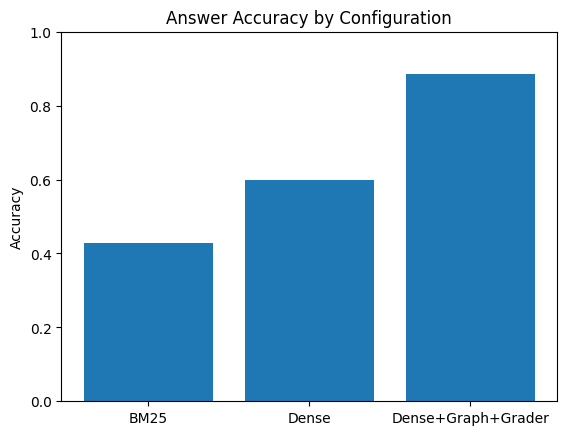

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("eval/details.csv")

acc = (
    df.groupby("config")["Judge"]
      .mean()
      .reset_index()
)

plt.figure()
plt.bar(acc["config"], acc["Judge"])
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.title("Answer Accuracy by Configuration")
plt.show()


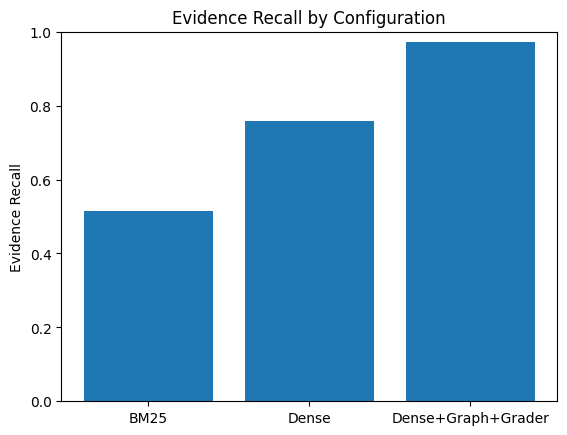

In [ ]:
rec = (
    df.groupby("config")["evidence_recall"]
      .mean()
      .reset_index()
)

plt.figure()
plt.bar(rec["config"], rec["evidence_recall"])
plt.ylabel("Evidence Recall")
plt.ylim(0, 1)
plt.title("Evidence Recall by Configuration")
plt.show()

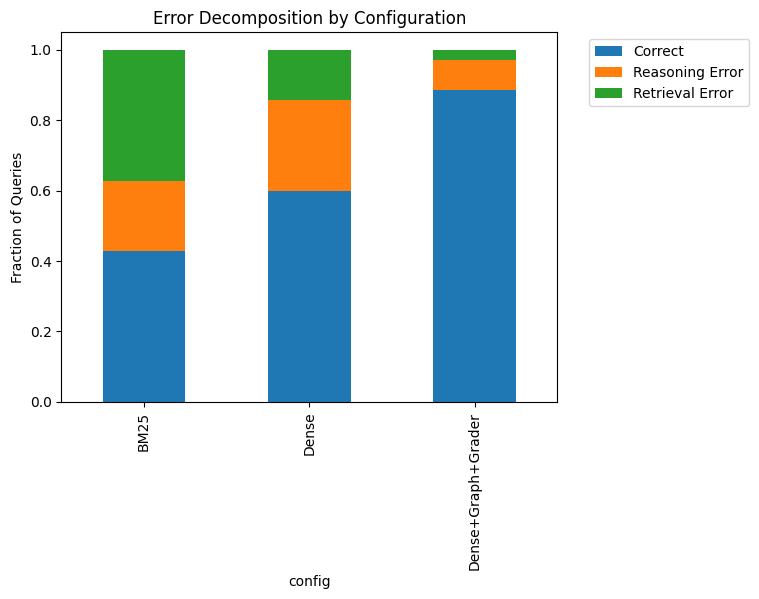

In [ ]:
def error_type(row):
    if row["evidence_recall"] == 0:
        return "Retrieval Error"
    if row["Judge"] == 0:
        return "Reasoning Error"
    return "Correct"

df["error_type"] = df.apply(error_type, axis=1)

pd.crosstab(df["config"], df["error_type"], normalize="index") \
  .plot(kind="bar", stacked=True)

plt.ylabel("Fraction of Queries")
plt.title("Error Decomposition by Configuration")
plt.legend(bbox_to_anchor=(1.05,1))
plt.show()